# 1_data_prep_Bob
streamlined notebook showing the current routine of grid loading and trimming before we save in the form used for training and testing pitchforks

- duplicated for different grids
- upstream of sandbox files used to test new data augmentations and make plots - do not mess around with grids here!

In [2]:
#misc
import pandas as pd
import numpy as np
import time
import os

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

## load in the grid:

In [3]:
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)

#check column headers we have to work with
print("check columns: " + str([column for column in df_full.columns.values]))

check columns: ['index', 'dirname', 'filename', 'model_number', 'evol_stage', 'initial_mass', 'initial_Yinit', 'initial_Zinit', 'initial_feh', 'initial_MLT', 'initial_fov', 'star_mass', 'star_age', 'ms_age', 'frac_age', 'effective_T', 'luminosity', 'radius', 'log_g', 'surface_h1', 'surface_he4', 'surface_Z', 'star_feh', 'center_h1', 'center_he4', 'log_center_T', 'log_center_Rho', 'he_core_mass', 'delta_nu', 'delta_Pg', 'nu_max', 'acoustic_cutoff', 'nu_0_1', 'nu_0_2', 'nu_0_3', 'nu_0_4', 'nu_0_5', 'nu_0_6', 'nu_0_7', 'nu_0_8', 'nu_0_9', 'nu_0_10', 'nu_0_11', 'nu_0_12', 'nu_0_13', 'nu_0_14', 'nu_0_15', 'nu_0_16', 'nu_0_17', 'nu_0_18', 'nu_0_19', 'nu_0_20', 'nu_0_21', 'nu_0_22', 'nu_0_23', 'nu_0_24', 'nu_0_25', 'nu_0_26', 'nu_0_27', 'nu_0_28', 'nu_0_29', 'nu_0_30', 'nu_0_31', 'nu_0_32', 'nu_0_33', 'nu_0_34', 'nu_0_35', 'nu_0_36', 'nu_0_37', 'nu_0_38', 'nu_0_39', 'nu_0_40']


In [4]:
len(df_full['dirname'].unique())

5388

## data prep:
cuts and scalings typically informed by messing around in grid_sandbox files

### pre prep plots
show some tracks and distributions for grid points before any cuts are made

In [17]:
def plot_tracks(df,track_id='dirname',effective_T='effective_T', luminosity='luminosity', star_age='star_age',title='', save=0, n=25,seed=42):
    
    track_id_df = pd.DataFrame(df[track_id].unique(), columns=[track_id]).sample(n=n, random_state=seed)
    
    #sample n tracks:
    i = 0
    for id in track_id_df[track_id]:
        if i == 0:
            track = df[df[track_id] == id]
            plot_points = pd.DataFrame(track,columns=[track_id, effective_T, luminosity, star_age])
            i+=1
        else:    
            track = df[df[track_id] == id]
            plot_points = pd.concat([plot_points, track])

    #plotting
    fig, ax = plt.subplots(figsize=(10,10))
    
    plt.scatter(np.log10(plot_points["effective_T"]), np.log10(plot_points["luminosity"]), c=plot_points["star_age"])
    cbar = plt.colorbar()
    cbar.ax.set_ylabel("age/Gyr")
    ax.set_ylabel("logL")
    ax.set_xlabel("logTeff")
    ax.set_title(title+" "+ time.strftime("%Y-%m-%d %H:%M:%S"))
    ax.invert_xaxis()
    fig.tight_layout
    
    #optional, save fig
    if save==1:
        figdir = "figs/data_prep_Li/tracks/"+ title + time.strftime("%Y%m%d-%H%M%S")
        plt.savefig(figdir + ".png", transparent="false", facecolor="white", bbox_inches="tight")
        
    plt.show()


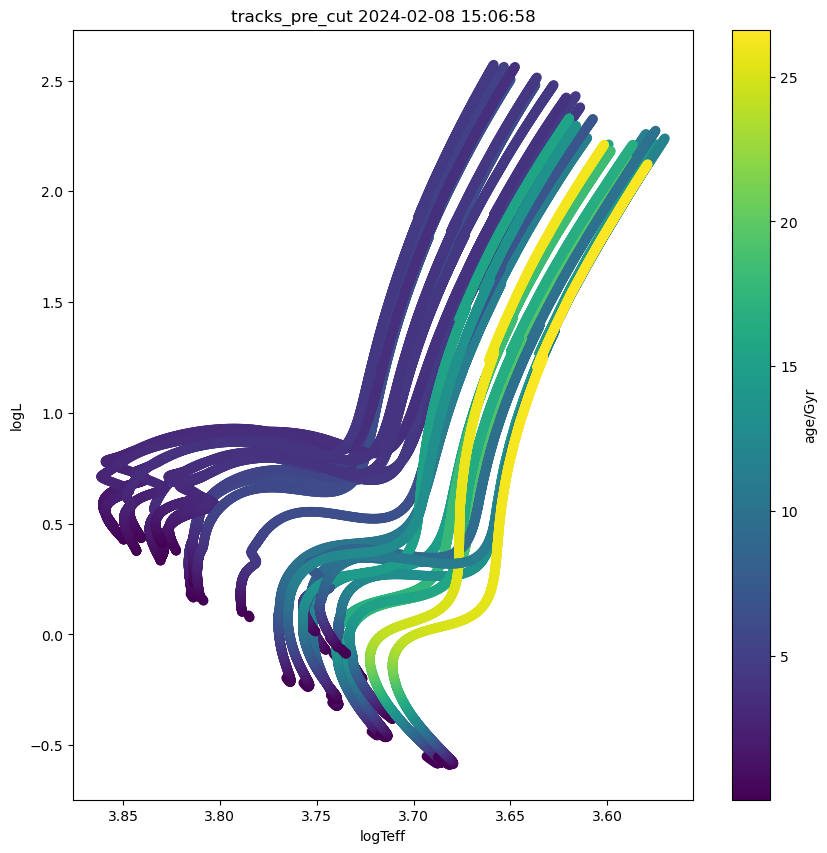

In [18]:
plot_tracks(df_full, title='tracks_pre_cut', save=1)

## post prep plots
show some tracks post prep - this is the dataset we'll use for training!

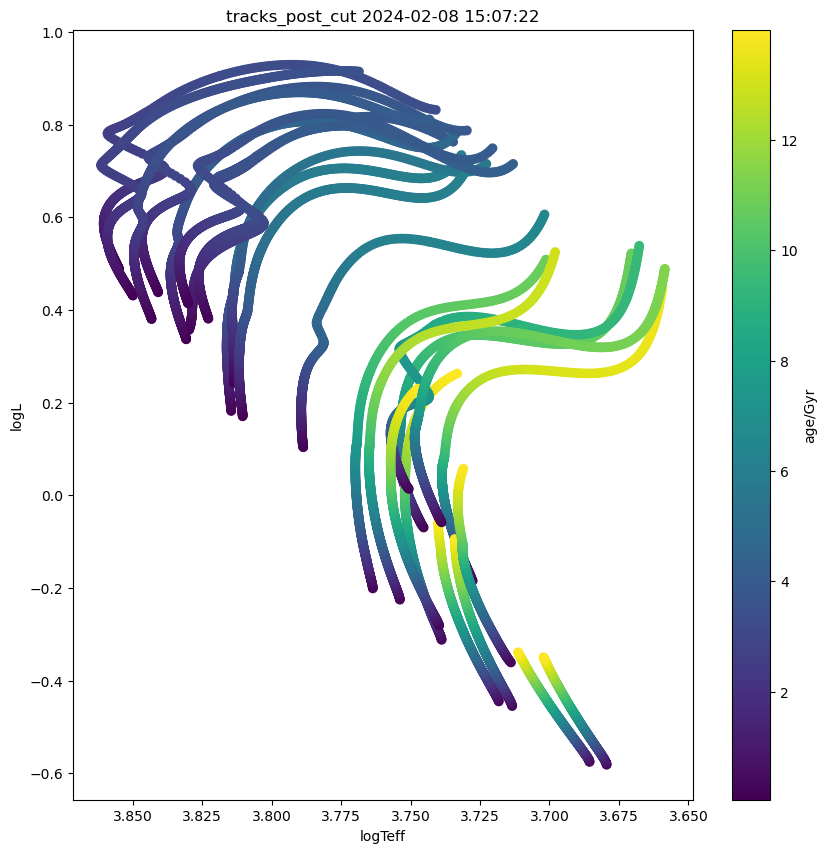

In [19]:
# load in grid and make cuts
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)
df = df_full[df_full["log_g"] >= 3.6]
df = df[df["star_age"] <= 14]
df = df[df["frac_age"] >= 0.015]

inputs = ['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']
outputs = ['radius', 'luminosity','effective_T', 'star_feh'] + [f'nu_0_{i+1}' for i in range(3,40)]

df = df.loc[(df[[f'nu_0_{i+1}' for i in range(3,40)]] != 0).all(axis=1)]

df.dropna(inplace=True)

df["log_star_age"] = np.log10(df["star_age"])
df["log_radius"] = np.log10(df["radius"])
df["log_luminosity"] = np.log10(df["luminosity"])
df["log_effective_T"] = np.log10(df["effective_T"])

df[[f'log_nu_0_{i+1}' for i in range(3,40)]] = np.log10(df[[f'nu_0_{i+1}' for i in range(3,40)]])

plot_tracks(df, title='tracks_post_cut', save=1)

## save prepared grid:

In [20]:
"""
save as hdf
"""
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)
df = df_full[df_full["log_g"] >= 3.6]
df = df[df["star_age"] <= 14]
df = df[df["frac_age"] >= 0.015]
df = df[df["initial_MLT"] <= 2]

inputs = ['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']
outputs = ['radius', 'luminosity','effective_T', 'surface_Z', 'nu_max', 'delta_nu']

cols = inputs + outputs

df = df[cols]

df.dropna(inplace=True)

df = df.sample(n=792198, random_state=42)

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,delta_nu
count,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000
mean,1.020928,0.014158,0.281968,1.800434,5.337817,1.392278,2.188875,5769.945558,0.013057,2144.494362,103.697949
std,0.115940,0.009543,0.028031,0.099999,3.500584,0.496634,1.567627,571.439401,0.009448,1114.943956,41.899789
min,0.800000,0.003869,0.240000,1.700000,0.029664,0.716057,0.132426,4099.843268,0.001355,431.750387,31.641090
25%,0.920000,0.006293,0.260000,1.700000,2.540991,1.026434,1.013962,5395.170704,0.005270,1201.566502,69.309725
50%,1.020000,0.010769,0.280000,1.900000,4.663161,1.233171,1.834036,5753.825658,0.010201,2086.086045,104.253064
75%,1.120000,0.020073,0.300000,1.900000,7.687273,1.642987,2.934617,6112.460646,0.018846,2908.642565,134.505865
max,1.200000,0.038980,0.320000,1.900000,13.999974,2.873431,11.612924,7995.935261,0.039035,5714.523485,207.403980


/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

Text(0.5, 1.02, 'bob inputs')

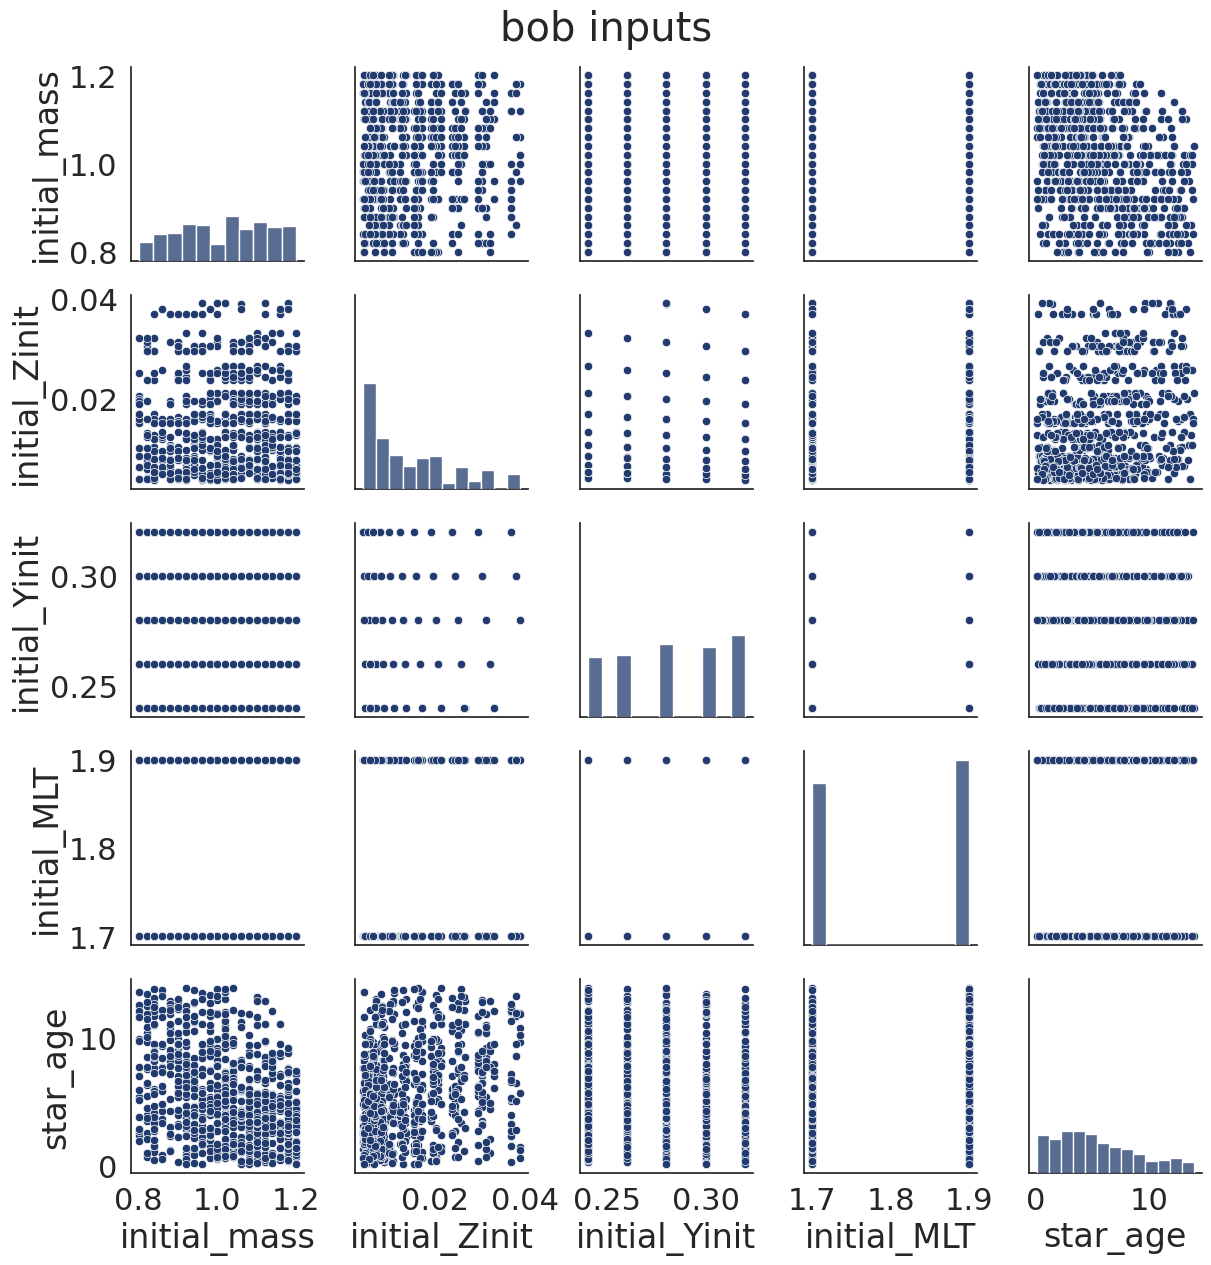

In [22]:
sns.set(font_scale=2)
sns.set_style(style="white")
sns.set_palette("cividis")
ax = sns.pairplot(df[['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']].sample(frac=0.001), diag_kind="hist")
ax.fig.suptitle('bob inputs', y=1.02)

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

Text(0.5, 1.02, 'bob outputs')

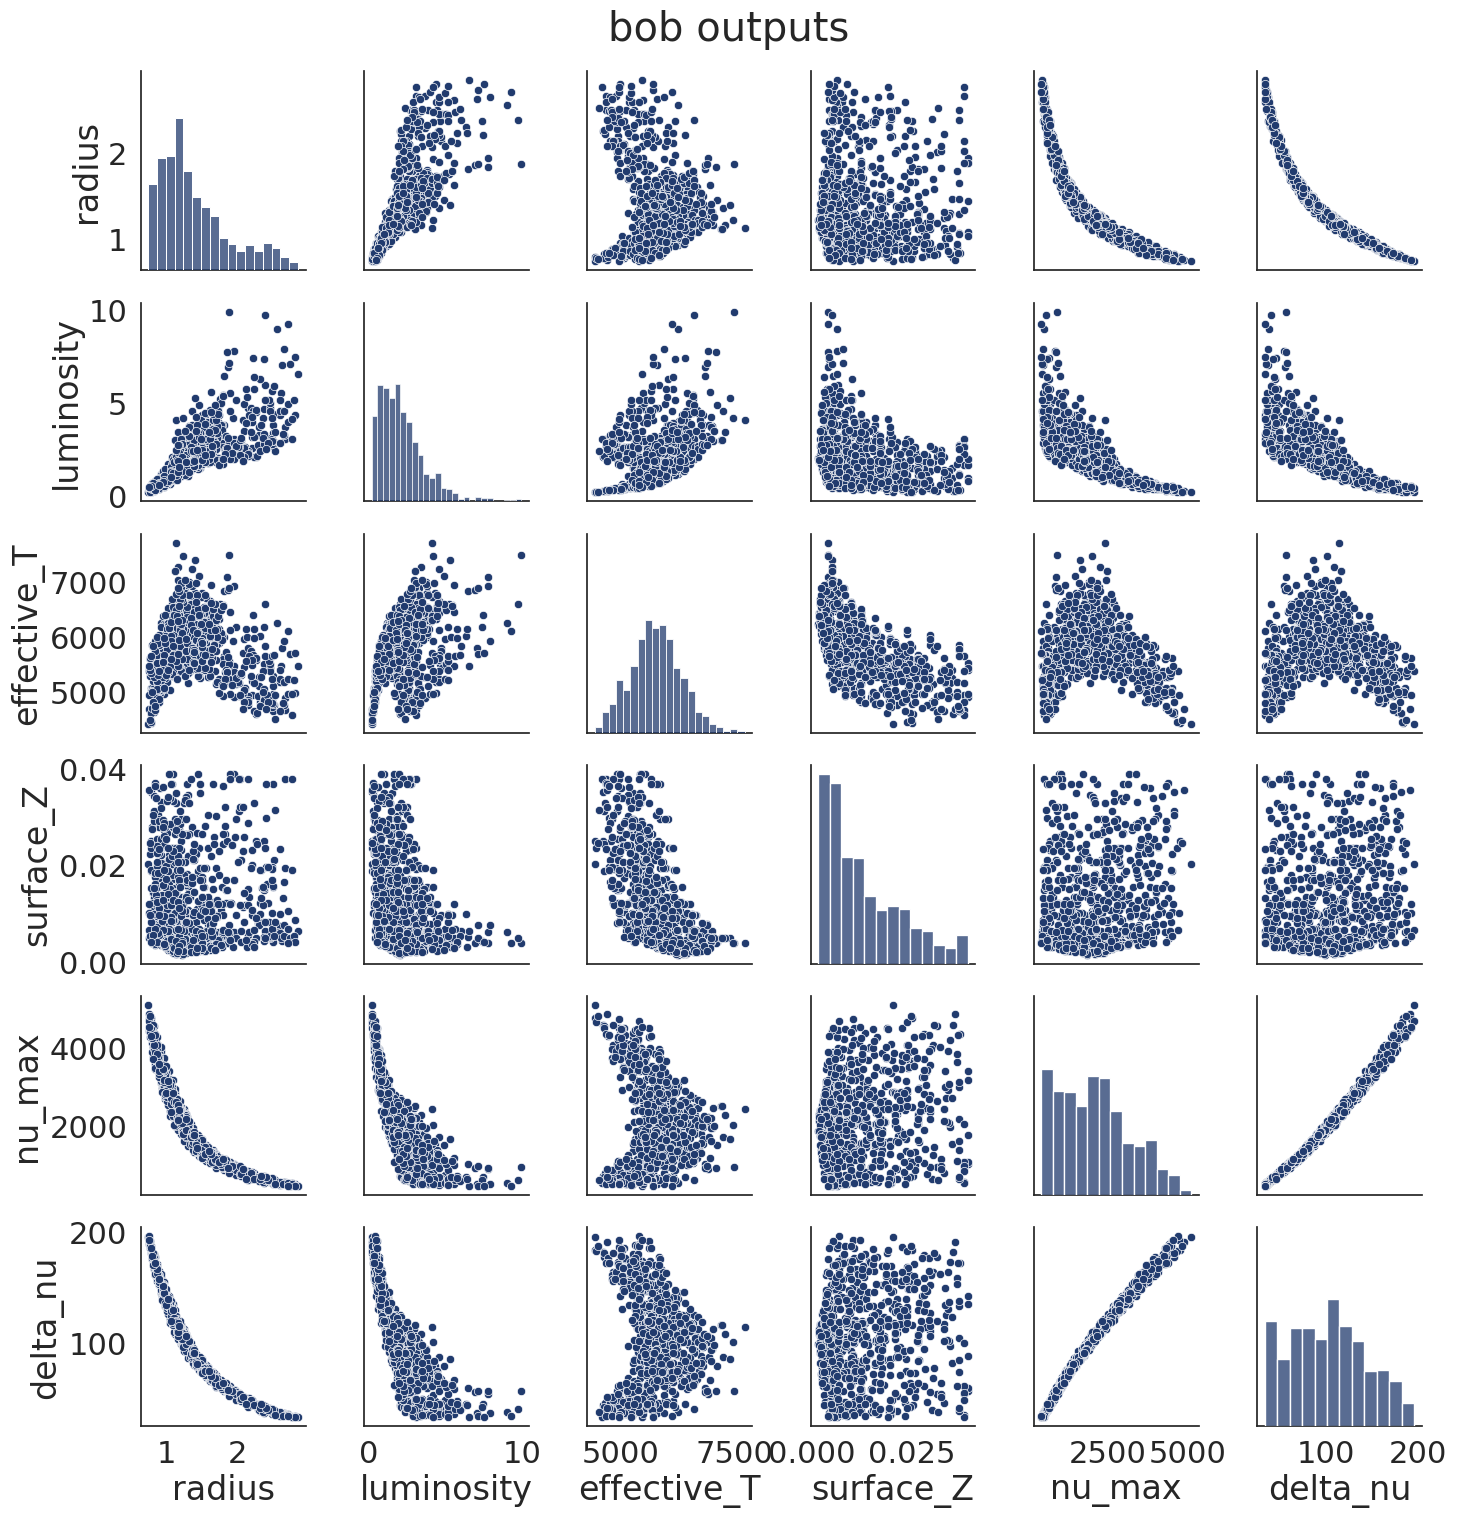

In [24]:
sns.set(font_scale=2)
sns.set_style(style="white")
sns.set_palette("cividis")
ax = sns.pairplot(df[['radius', 'luminosity','effective_T', 'surface_Z', 'nu_max', 'delta_nu']].sample(frac=0.001), diag_kind="hist")
ax.fig.suptitle('bob outputs', y=1.02)

In [6]:
"""
save as hdf
"""
df_full = pd.concat([pd.read_hdf("/home/oxs235/datastorage/repos_data/ojscutt/mesa_ajl/data/grid2p5a/grid.h5", key=f"m{0.8 + i*0.02:.2f}") for i in range(21)], ignore_index=True)
df = df_full[df_full["log_g"] >= 3.6]
df = df[df["star_age"] <= 14]
df = df[df["frac_age"] >= 0.015]
df = df[df["initial_MLT"] <= 2]

inputs = ['initial_mass', 'initial_Zinit', 'initial_Yinit', 'initial_MLT', 'star_age']
outputs = ['radius', 'luminosity','effective_T', 'surface_Z', 'nu_max', 'delta_nu']

cols = inputs + outputs

df = df[cols]

df.dropna(inplace=True)

df = df.sample(n=792198, random_state=42)

df.describe()

df.to_hdf("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/keystone/bob.h5", key="df")


for column in df.columns:
    df['log_'+column] = np.log10(df[column])

for column in df.columns:
    df[column+"_std"] = (df[column]-df[column].mean())/df[column].std()

df.to_hdf("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/keystone/bob.h5", key="df")